In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

### load data set 

In [2]:
df= pd.read_csv("batting_stats.csv",index_col=[0])

In [3]:
df

,batsman,team,matches,innings,runs,impact,average,strike_rate,not_outs,high_score,balls_faced,hundreds,fifties,ducks,fours,sixes
position,,,,,,,,,,,,,,,,
1,Abhishek Sharma,SRH,8,8,380,395.6,54.28,212.29,1,135,179,1,3,2,36,28
2,KL Rahul,DC,8,8,358,317.6,51.14,185.49,1,152,193,1,2,1,36,19
3,Vaibhav Sooryavanshi,RR,8,8,357,433.2,44.62,234.86,0,103,152,1,2,1,31,32
4,Virat Kohli,RCB,8,8,351,282.2,58.50,162.50,2,81,216,0,3,0,37,14
5,Heinrich Klaasen,SRH,8,8,349,258.6,49.85,149.78,1,62,233,0,3,0,25,14
6,Shubman Gill,GT,7,7,330,279.1,47.14,148.64,0,86,222,0,3,0,30,14
7,Sai Sudarshan,GT,8,8,322,274.4,40.25,163.45,0,100,197,1,2,1,32,17
8,Ishan Kishan,SRH,8,8,312,381.7,39.00,198.72,0,91,157,0,3,1,35,16
9,Sanju Samson,CSK,8,8,304,369.4,50.66,169.83,2,115,179,2,0,0,33,15


### Data  preprocessing

In [4]:
df.dtypes

batsman            str
team               str
matches          int64
innings          int64
runs             int64
impact         float64
average        float64
strike_rate    float64
not_outs         int64
high_score       int64
balls_faced      int64
hundreds         int64
fifties          int64
ducks            int64
fours            int64
sixes            int64
dtype: object

In [5]:
# Inforamtion about data set
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 1 to 15
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   batsman      15 non-null     str    
 1   team         15 non-null     str    
 2   matches      15 non-null     int64  
 3   innings      15 non-null     int64  
 4   runs         15 non-null     int64  
 5   impact       15 non-null     float64
 6   average      15 non-null     float64
 7   strike_rate  15 non-null     float64
 8   not_outs     15 non-null     int64  
 9   high_score   15 non-null     int64  
 10  balls_faced  15 non-null     int64  
 11  hundreds     15 non-null     int64  
 12  fifties      15 non-null     int64  
 13  ducks        15 non-null     int64  
 14  fours        15 non-null     int64  
 15  sixes        15 non-null     int64  
dtypes: float64(3), int64(11), str(2)
memory usage: 2.2 KB


In [6]:
# Describe data set 
df.describe()

,matches,innings,runs,impact,average,strike_rate,not_outs,high_score,balls_faced,hundreds,fifties,ducks,fours,sixes
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,7.666667,7.466667,310.000000,308.680000,48.421333,183.368667,0.933333,91.133333,173.266667,0.400000,2.466667,0.466667,29.400000,18.000000
std,0.617213,0.833809,43.975643,65.499871,8.832509,30.988700,0.798809,26.733785,35.879693,0.632456,0.915475,0.639940,6.609517,6.035609
min,6.000000,6.000000,242.000000,233.400000,38.570000,148.640000,0.000000,60.000000,102.000000,0.000000,0.000000,0.000000,16.000000,11.000000
25%,7.500000,7.000000,274.500000,251.800000,41.330000,158.055000,0.000000,74.000000,151.000000,0.000000,2.000000,0.000000,27.000000,14.000000
50%,8.000000,8.000000,312.000000,282.200000,47.140000,185.490000,1.000000,86.000000,178.000000,0.000000,3.000000,0.000000,31.000000,16.000000
75%,8.000000,8.000000,350.000000,366.550000,52.710000,195.665000,1.500000,101.500000,195.000000,1.000000,3.000000,1.000000,34.000000,20.000000
max,8.000000,8.000000,380.000000,433.200000,69.750000,249.010000,2.000000,152.000000,233.000000,2.000000,4.000000,2.000000,37.000000,32.000000


In [7]:
# first 7 rows
df.head(7)

,batsman,team,matches,innings,runs,impact,average,strike_rate,not_outs,high_score,balls_faced,hundreds,fifties,ducks,fours,sixes
position,,,,,,,,,,,,,,,,
1,Abhishek Sharma,SRH,8,8,380,395.6,54.28,212.29,1,135,179,1,3,2,36,28
2,KL Rahul,DC,8,8,358,317.6,51.14,185.49,1,152,193,1,2,1,36,19
3,Vaibhav Sooryavanshi,RR,8,8,357,433.2,44.62,234.86,0,103,152,1,2,1,31,32
4,Virat Kohli,RCB,8,8,351,282.2,58.50,162.50,2,81,216,0,3,0,37,14
5,Heinrich Klaasen,SRH,8,8,349,258.6,49.85,149.78,1,62,233,0,3,0,25,14
6,Shubman Gill,GT,7,7,330,279.1,47.14,148.64,0,86,222,0,3,0,30,14
7,Sai Sudarshan,GT,8,8,322,274.4,40.25,163.45,0,100,197,1,2,1,32,17


In [8]:
# last seven rows
df.tail(7)

,batsman,team,matches,innings,runs,impact,average,strike_rate,not_outs,high_score,balls_faced,hundreds,fifties,ducks,fours,sixes
position,,,,,,,,,,,,,,,,
9,Sanju Samson,CSK,8,8,304,369.4,50.66,169.83,2,115,179,2,0,0,33,15
10,Prabhsimran Singh,PBKS,7,6,287,318.8,57.40,192.61,1,80,149,0,3,1,31,16
11,Shreyas Iyer,PBKS,7,6,279,241.3,69.75,186.00,2,71,150,0,4,0,17,21
12,Jos Buttler,GT,8,8,270,236.2,38.57,151.68,1,60,178,0,2,0,31,11
13,Yashasvi Jaiswal,RR,8,8,255,233.4,42.50,153.61,2,77,166,0,2,0,29,12
14,Priyansh Arya,PBKS,6,6,254,363.7,42.33,249.01,0,93,102,0,2,0,16,25
15,Devdutt Padikkal,RCB,8,7,242,245.0,40.33,192.06,1,61,126,0,3,0,22,16


In [9]:
# Finding null values


In [10]:
df.isnull().sum()

batsman        0
team           0
matches        0
innings        0
runs           0
impact         0
average        0
strike_rate    0
not_outs       0
high_score     0
balls_faced    0
hundreds       0
fifties        0
ducks          0
fours          0
sixes          0
dtype: int64

In [48]:
df[df.duplicated()]

,batsman,team,matches,innings,runs,impact,average,strike_rate,not_outs,high_score,balls_faced,hundreds,fifties,ducks,fours,sixes
position,,,,,,,,,,,,,,,,


## EDA Analysis


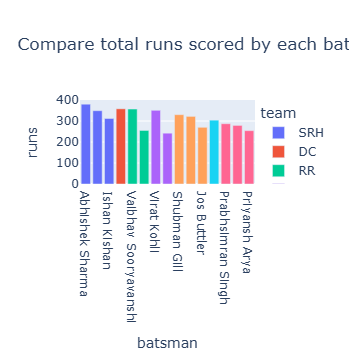

In [44]:
px.bar(df, x="batsman", y="runs", color="team", title="Compare total runs scored by each batsman across teams")

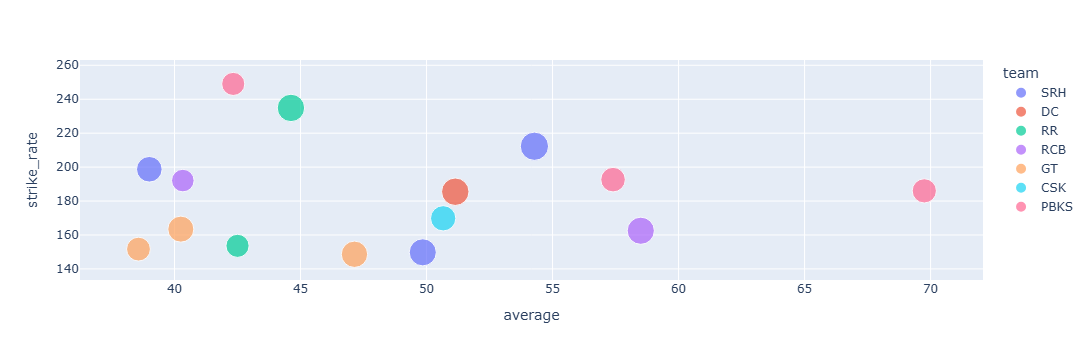

In [32]:
px.scatter(df, x="average", y="strike_rate", color="team", size="runs")


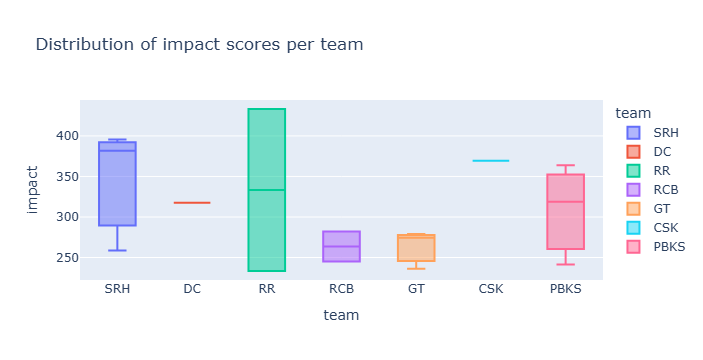

In [43]:
px.box(df, x="team", y="impact", color="team", title="Distribution of impact scores per team")  

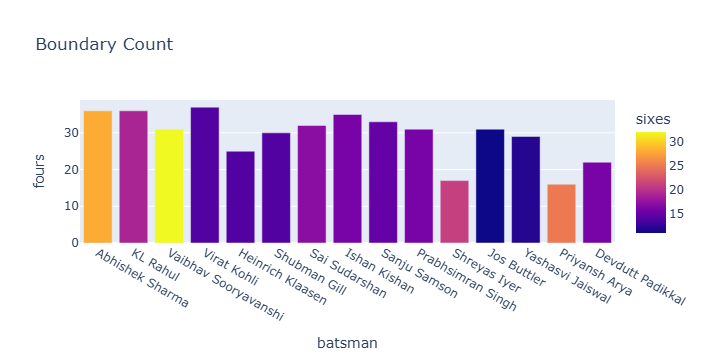

In [42]:
px.bar(df, x="batsman", y="fours", color="sixes", title="Boundary Count" ) 

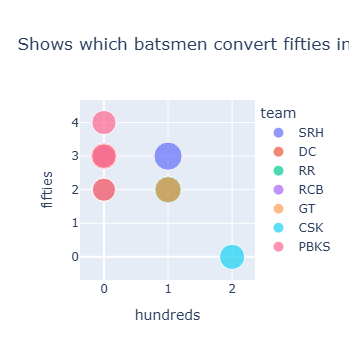

In [40]:
px.scatter(df, x="hundreds", y="fifties", size="runs", color="team", title="Shows which batsmen convert fifties into hundreds") 

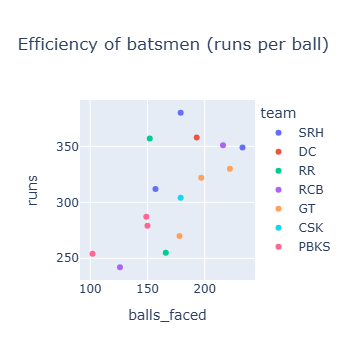

In [39]:
fig=px.scatter(df, x="balls_faced", y="runs", color="team", title=("Efficiency of batsmen (runs per ball)"))
fig.show()

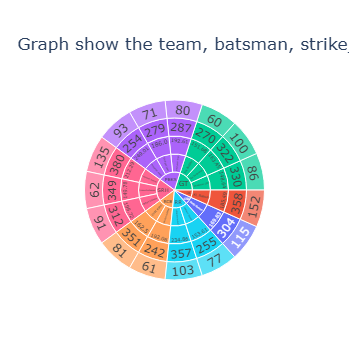

-Color show the team


In [45]:
# Sunburst Graph

#  To show the team, batsman,strike_rate,runs, and high_score
fig = px.sunburst(df,path=["team","batsman","strike_rate","runs","high_score"],color="team",title="Graph show the team, batsman, strike_rate, runs, and high_score")
fig.show()


print("-Color show the team")